# Epilepsy Detection: 1D CNN Model

Loads preprocessed data from the preprocessing pipeline and trains a 1D CNN.

**Inputs:** `X_train.npy`, `X_test.npy`, `y_train.npy`, `y_test.npy`, `preprocessing_pipeline.pkl`

**3-class:** 0=Healthy | 1=Interictal | 2=Ictal

## Install & Import

In [1]:
import tensorflow as tf

print(tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("MPS devices:", tf.config.list_physical_devices('MPS'))


2.16.2
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
MPS devices: []


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

print(f'TensorFlow : {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.16.2
GPU available: True


## Load Preprocessed Data

In [3]:
import os
os.chdir('/Users/shruthinagappan/Documents/Anvaya/venv_tf')
print(os.getcwd())
print(os.listdir('.'))

/Users/shruthinagappan/Documents/Anvaya/venv_tf
['class_balance_comparison.png', 'extracted_features.npy', 'pca_2d_visualization.png', '.DS_Store', 'bin', 'dataset', 'include', 'epilepsy_preprocessing.ipynb', 'vmd_decomposition_comparison.png', 'checkpoints', 'etc', 'eeg_signals_overview.png', 'pyvenv.cfg', 'pca_variance_explained.png', 'y_train.npy', 'feature_selection_scores.png', 'preprocessing_pipeline.pkl', 'lib', 'y_test.npy', 'X_test.npy', 'feature_labels.npy', 'X_train.npy', 'epilepsy_cnn_model.ipynb', 'preprocessing_comparison.png', 'statistical_comparison.png', 'share']


In [4]:
X_train = np.load('X_train.npy')
X_test  = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_test  = np.load('y_test.npy')

if os.path.exists('preprocessing_pipeline.pkl'):
    with open('preprocessing_pipeline.pkl', 'rb') as f:
        pipeline = pickle.load(f)
    n_classes   = pipeline.get('n_classes', 3)
    class_names = pipeline.get('class_map', {0: 'Healthy', 1: 'Interictal', 2: 'Ictal'})
    print('preprocessing pipeline loaded')
else:
    print('preprocessing_pipeline.pkl not found - using defaults')
    n_classes   = len(np.unique(y_train))
    class_names = {0: 'Healthy', 1: 'Interictal', 2: 'Ictal'}

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'y_train : {y_train.shape}  |  y_test : {y_test.shape}')
print(f'Classes : {n_classes}  ->  {list(class_names.values())}')
print('\nTrain class distribution:')
unique, counts = np.unique(y_train, return_counts=True)
for lbl, cnt in zip(unique, counts):
    pct = cnt / len(y_train) * 100
    print(f'  {class_names.get(int(lbl), lbl)}: {cnt}  ({pct:.1f}%)')

preprocessing pipeline loaded
X_train : (480, 30)  |  X_test : (121, 30)
y_train : (480,)  |  y_test : (121,)
Classes : 3  ->  ['Healthy', 'Interictal', 'Ictal']

Train class distribution:
  Healthy: 160  (33.3%)
  Interictal: 160  (33.3%)
  Ictal: 160  (33.3%)


## Prepare Data for 1D CNN

Reshape `(n_samples, n_features)` → `(n_samples, n_features, 1)` and one-hot encode labels.

In [5]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1).astype(np.float32)
X_test_cnn  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1).astype(np.float32)

y_train_ohe = keras.utils.to_categorical(y_train, num_classes=n_classes)
y_test_ohe  = keras.utils.to_categorical(y_test,  num_classes=n_classes)

input_length = X_train_cnn.shape[1]
print(f'CNN input  : (batch, {input_length}, 1)')
print(f'Label shape: {y_train_ohe.shape}')

CNN input  : (batch, 30, 1)
Label shape: (480, 3)


## Build the 1D CNN Model

```
Conv1D(24, k=5) → BN → ReLU
Conv1D(16, k=3) → BN → ReLU → Dropout
Conv1D(8,  k=3) → BN → ReLU
GlobalAvgPool
Dense(64) → ReLU → Dropout
Dense(n_classes) → Softmax
```

In [6]:
def build_cnn(input_length, n_classes, dropout_rate=0.4):
    inputs = keras.Input(shape=(input_length, 1), name='eeg_input')

    # Conv Block 1
    x = layers.Conv1D(24, kernel_size=5, padding='same', use_bias=False, name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)

    # Conv Block 2
    x = layers.Conv1D(16, kernel_size=3, padding='same', use_bias=False, name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(dropout_rate * 0.5, name='drop_conv2')(x)

    # Conv Block 3
    x = layers.Conv1D(8, kernel_size=3, padding='same', use_bias=False, name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)

    # Classifier head
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4), name='fc1')(x)
    x = layers.Dropout(dropout_rate, name='drop_fc1')(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs, outputs, name='EEG_CNN')

model = build_cnn(input_length, n_classes)
model.summary()

2026-02-19 22:24:44.840314: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-02-19 22:24:44.840333: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-19 22:24:44.840338: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-02-19 22:24:44.840352: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-19 22:24:44.840364: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "EEG_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 30, 24)         │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 30, 24)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 30, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 30, 16)         │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 30, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_conv2 (Dropout)            │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 30, 8)          │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 30, 8)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 30, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc1 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619 (10.23 KB)

 Trainable params: 2,523 (9.86 KB)

 Non-trainable params: 96 (384.00 B)

## Compile

In [7]:
LEARNING_RATE = 2e-4
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f'Optimizer : Adam  lr={LEARNING_RATE}')
print(f'Classes   : {list(class_names.values())}')

Optimizer : Adam  lr=0.0002
Classes   : ['Healthy', 'Interictal', 'Ictal']


## Callbacks

In [8]:
os.makedirs('checkpoints', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8,
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath='checkpoints/best_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

## Train

In [9]:
NUM_EPOCHS = 500
BATCH_SIZE = 64

history = model.fit(
    X_train_cnn, y_train_ohe,
    validation_split=0.15,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

epochs_run = len(history.history['loss'])
print('Training complete  ({epochs_run} epochs)')

Epoch 1/500


2026-02-19 22:24:46.141841: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.3134 - loss: 1.1017
Epoch 1: val_accuracy improved from None to 0.38889, saving model to checkpoints/best_model.keras

Epoch 1: finished saving model to checkpoints/best_model.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step - accuracy: 0.3186 - loss: 1.1012 - val_accuracy: 0.3889 - val_loss: 1.0878 - learning_rate: 2.0000e-04
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3396 - loss: 1.1085
Epoch 2: val_accuracy did not improve from 0.38889
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3431 - loss: 1.1047 - val_accuracy: 0.3889 - val_loss: 1.0881 - learning_rate: 2.0000e-04
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3201 - loss: 1.1005
Epoch 3: val_accuracy did not improve from 0.38889
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3113 - loss: 1.0985 - val_accuracy: 0.3889 - val_loss: 1.0880 - learning_rate: 2.0000e-04
Epoch 4/500
5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3356

## Training Curves

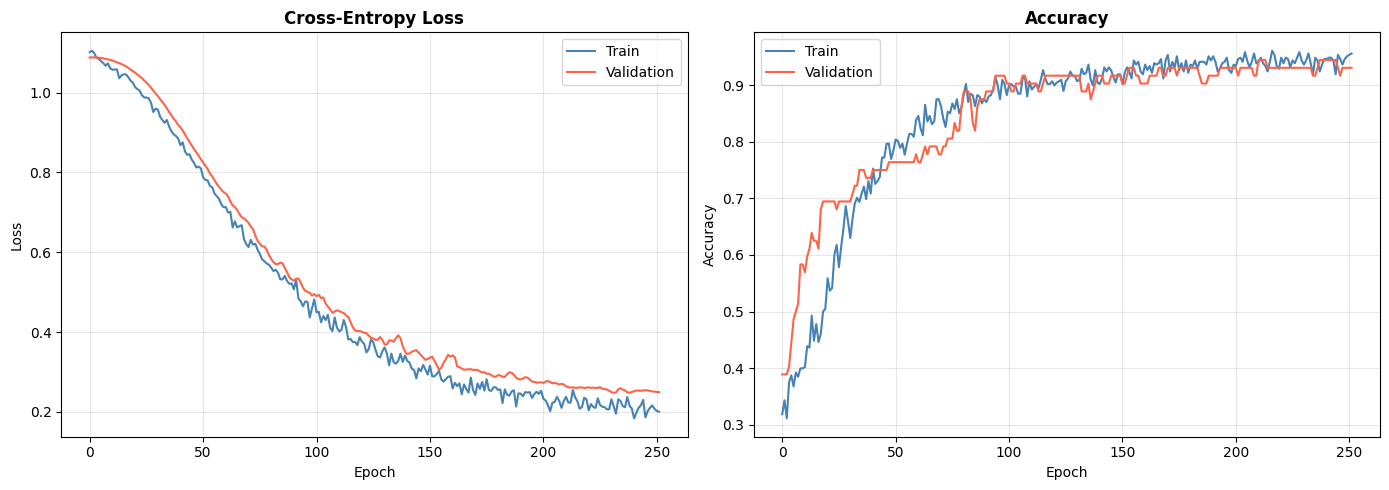

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train',      color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation', color='tomato')
axes[0].set_title('Cross-Entropy Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train',      color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation', color='tomato')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Test Set Evaluation

In [11]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test_ohe, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc * 100:.2f}%')

y_pred_proba = model.predict(X_test_cnn, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test.astype(int)
label_names = [class_names.get(i, str(i)) for i in range(n_classes)]

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=label_names))

Test Loss     : 0.2247
Test Accuracy : 95.04%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.95      0.93      0.94        40
  Interictal       1.00      0.93      0.96        40
       Ictal       0.91      1.00      0.95        41

    accuracy                           0.95       121
   macro avg       0.95      0.95      0.95       121
weighted avg       0.95      0.95      0.95       121



## Confusion Matrix

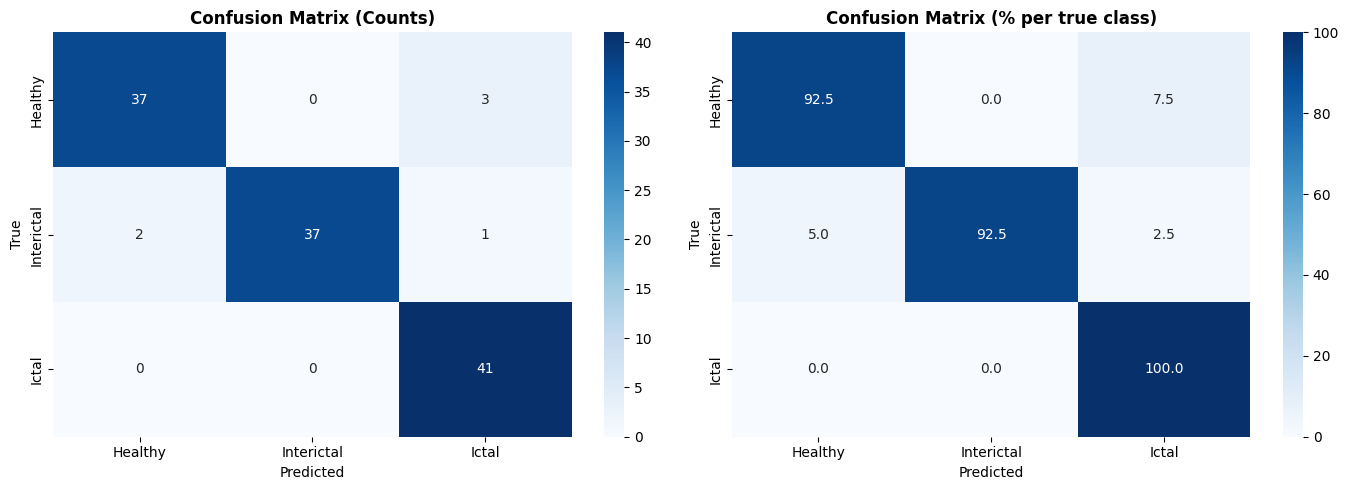

In [12]:
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (% per true class)', fontweight='bold')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC Curves

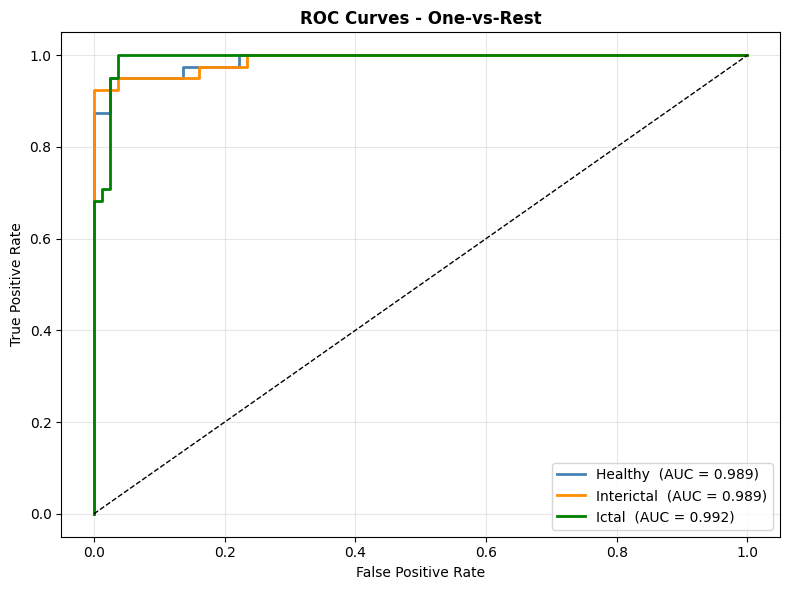

Macro-average AUC: 0.9901


In [13]:
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{label_names[i]}  (AUC = {roc_auc_val:.3f})')

plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - One-vs-Rest', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

macro_auc = roc_auc_score(y_true_bin, y_pred_proba, multi_class='ovr', average='macro')
print(f'Macro-average AUC: {macro_auc:.4f}')

## Save Model

In [14]:
model.save('epilepsy_cnn_model.keras')
print('✓ Model saved: epilepsy_cnn_model.keras')

with open('training_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals]
               for k, vals in history.history.items()}, f, indent=2)
print('✓ History saved: training_history.json')

✓ Model saved: epilepsy_cnn_model.keras
✓ History saved: training_history.json


## Inference on New Samples

Apply the full preprocessing pipeline to a raw feature vector and run inference.

In [15]:
loaded_model = keras.models.load_model('epilepsy_cnn_model.keras')

with open('preprocessing_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

scaler   = pipeline['scaler']
selector = pipeline['selector']
pca      = pipeline['pca']
cmap     = pipeline.get('class_map', {0: 'Healthy', 1: 'Interictal', 2: 'Ictal'})


def predict_sample(raw_features):
    """
    Predict from a raw feature vector (before scaler/selector/PCA).
    raw_features: 1-D array matching rows in extracted_features.npy
    """
    x = scaler.transform(raw_features.reshape(1, -1))

    # selector can be a tuple (hybrid method) or single object
    if isinstance(selector, tuple):
        x = np.hstack([selector[0].transform(x), selector[1].transform(x)])
    else:
        x = selector.transform(x)

    x = pca.transform(x)                 # (1, n_pca)
    x = x.reshape(1, x.shape[1], 1)      # (1, n_pca, 1)

    proba = loaded_model.predict(x, verbose=0)[0]
    pred  = int(np.argmax(proba))
    return {
        'predicted_class': pred,
        'class_name'     : cmap.get(pred, str(pred)),
        'confidence'     : float(proba[pred]),
        'probabilities'  : {cmap.get(i, str(i)): float(p) for i, p in enumerate(proba)}
    }

if os.path.exists('extracted_features.npy'):
    feats  = np.load('extracted_features.npy')
    result = predict_sample(feats[0])
    print('Demo prediction on first raw feature vector:')
    print(f'  Class      : {result["class_name"]} (id={result["predicted_class"]})')
    print(f'  Confidence : {result["confidence"] * 100:.1f}%')
    print(f'  All probs  : {result["probabilities"]}')
else:
    print('Demo on X_test_cnn[0:3]:')
    proba_demo = loaded_model.predict(X_test_cnn[:3], verbose=0)
    for i, p in enumerate(proba_demo):
        pred = int(np.argmax(p))
        conf = p[pred] * 100
        print(f'  Sample {i}: {class_names.get(pred)}  conf={conf:.1f}%')

Demo prediction on first raw feature vector:
  Class      : Healthy (id=0)
  Confidence : 96.6%
  All probs  : {'Healthy': 0.9663927555084229, 'Interictal': 0.02117493562400341, 'Ictal': 0.012432413175702095}


## Summary

In [16]:
print(f'Test Accuracy : {test_acc * 100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')
print(f'Macro AUC     : {macro_auc:.4f}')
print(f'Epochs run    : {epochs_run} / {NUM_EPOCHS}')
print('Files saved:')
print('  epilepsy_cnn_model.keras')
print('  checkpoints/best_model.keras')
print('  training_curves.png')
print('  confusion_matrix.png')
print('  roc_curves.png')
print('  training_history.json')

Test Accuracy : 95.04%
Test Loss     : 0.2247
Macro AUC     : 0.9901
Epochs run    : 252 / 500
Files saved:
  epilepsy_cnn_model.keras
  checkpoints/best_model.keras
  training_curves.png
  confusion_matrix.png
  roc_curves.png
  training_history.json


# Part 2: Bayesian-Optimized SVM
## 3-Class EEG Classification (Healthy / Interictal / Ictal)

Trains a second model on the same preprocessed data using a Support Vector Machine with hyperparameters tuned via **Bayesian Optimization** (Gaussian Process surrogate).

| | Detail |
|---|---|
| **Task** | Same 3-class problem as the CNN |
| **Features** | Same PCA-reduced vectors from `X_train.npy` / `X_test.npy` |
| **Tuning** | `BayesSearchCV` — 40 iterations, 5-fold stratified CV, scoring = ROC-AUC (OvR) |
| **Output** | `svm_epilepsy_model.pkl`, full metrics, comparison plot vs CNN |

## Install Extra Dependencies

In [17]:
!pip install scikit-optimize --break-system-packages -q
print('✓ scikit-optimize ready')


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✓ scikit-optimize ready


## Additional Imports

In [18]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler as SKScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, matthews_corrcoef,
                              average_precision_score)
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
import pickle as pkl
import time

print('SVM / Bayesian optimization imports ready')

SVM / Bayesian optimization imports ready


## 17. Bayesian Hyperparameter Search

| Hyperparameter | Space | Prior |
|---|---|---|
| `C` | [0.01, 1000] | log-uniform |
| `gamma` | [1e-4, 10] | log-uniform |
| `kernel` | rbf, poly, sigmoid | categorical |
| `class_weight` | None, balanced | categorical |

Scoring: **ROC-AUC one-vs-rest** (macro), 5-fold stratified CV.

In [19]:
search_space = {
    'svm__C'           : Real(1e-2, 1e3, prior='log-uniform'),
    'svm__gamma'       : Real(1e-4, 1e1, prior='log-uniform'),
    'svm__kernel'      : Categorical(['rbf', 'poly', 'sigmoid']),
    'svm__class_weight': Categorical([None, 'balanced']),
}

svm_pipe = Pipeline([
    ('svm', SVC(probability=True, random_state=42, max_iter=5000,
                decision_function_shape='ovr'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bayes_search = BayesSearchCV(
    estimator     = svm_pipe,
    search_spaces = search_space,
    n_iter        = 40,
    scoring       = 'roc_auc_ovr',
    cv            = cv,
    n_jobs        = -1,
    refit         = True,
    verbose       = 1,
    random_state  = 42
)

print('Starting Bayesian optimization  (40 iterations x 5-fold CV)...')
t0 = time.time()
bayes_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'\n Done in {elapsed:.1f}s')
print(f'Best CV ROC-AUC (OvR): {bayes_search.best_score_:.4f}')
print('\nBest hyperparameters:')
for k, v in bayes_search.best_params_.items():
    print(f'  {k}: {v}')

Starting Bayesian optimization  (40 iterations x 5-fold CV)...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 

## 18. Optimization Convergence

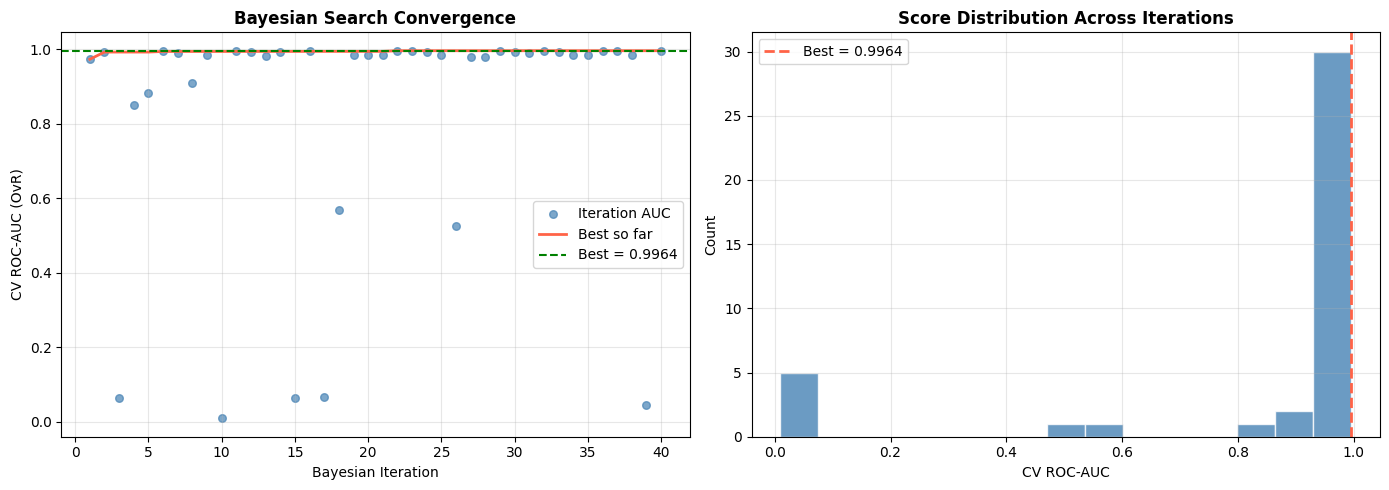

Saved: svm_convergence.png


In [20]:
scores      = bayes_search.cv_results_['mean_test_score']
best_so_far = np.maximum.accumulate(scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(range(1, len(scores)+1), scores, s=30, alpha=0.7,
                color='steelblue', label='Iteration AUC')
axes[0].plot(range(1, len(best_so_far)+1), best_so_far,
             color='tomato', lw=2, label='Best so far')
axes[0].axhline(bayes_search.best_score_, color='green', ls='--', lw=1.5,
                label=f'Best = {bayes_search.best_score_:.4f}')
axes[0].set_xlabel('Bayesian Iteration'); axes[0].set_ylabel('CV ROC-AUC (OvR)')
axes[0].set_title('Bayesian Search Convergence', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(scores, bins=15, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(bayes_search.best_score_, color='tomato', lw=2, ls='--',
                label=f'Best = {bayes_search.best_score_:.4f}')
axes[1].set_xlabel('CV ROC-AUC'); axes[1].set_ylabel('Count')
axes[1].set_title('Score Distribution Across Iterations', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: svm_convergence.png')

## 19. Evaluate Best SVM on Test Set

In [21]:
best_svm = bayes_search.best_estimator_

y_pred_svm   = best_svm.predict(X_test)
y_proba_svm  = best_svm.predict_proba(X_test)
y_true_int   = y_test.astype(int)

svm_acc  = (y_pred_svm == y_true_int).mean()
svm_bal  = balanced_accuracy_score(y_true_int, y_pred_svm)
svm_mcc  = matthews_corrcoef(y_true_int, y_pred_svm)

y_true_bin_ovr = label_binarize(y_true_int, classes=list(range(n_classes)))
svm_auc  = roc_auc_score(y_true_bin_ovr, y_proba_svm, multi_class='ovr', average='macro')

print('SVM TEST RESULTS  (Healthy / Interictal / Ictal)')
print(f'  Accuracy          : {svm_acc * 100:.2f}%')
print(f'  Balanced Accuracy : {svm_bal * 100:.2f}%')
print(f'  Macro ROC-AUC     : {svm_auc:.4f}')
print(f'  MCC               : {svm_mcc:.4f}')

print('\nClassification Report:')
print(classification_report(y_true_int, y_pred_svm,
                             target_names=list(class_names.values())))

SVM TEST RESULTS  (Healthy / Interictal / Ictal)
  Accuracy          : 99.17%
  Balanced Accuracy : 99.17%
  Macro ROC-AUC     : 0.9983
  MCC               : 0.9877

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.97      0.99        40
  Interictal       0.98      1.00      0.99        40
       Ictal       1.00      1.00      1.00        41

    accuracy                           0.99       121
   macro avg       0.99      0.99      0.99       121
weighted avg       0.99      0.99      0.99       121



## 20. SVM Confusion Matrix

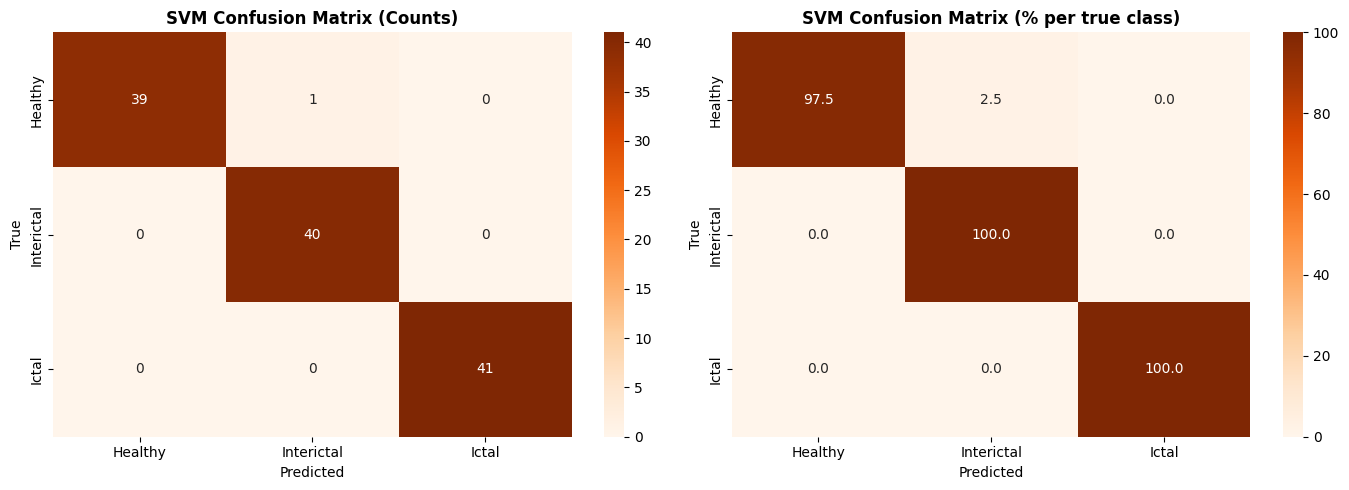

Saved: svm_confusion_matrix.png


In [22]:
cm_svm     = confusion_matrix(y_true_int, y_pred_svm)
cm_svm_pct = cm_svm.astype(float) / cm_svm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title('SVM Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

sns.heatmap(cm_svm_pct, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title('SVM Confusion Matrix (% per true class)', fontweight='bold')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: svm_confusion_matrix.png')

## 21. SVM ROC Curves (One-vs-Rest)

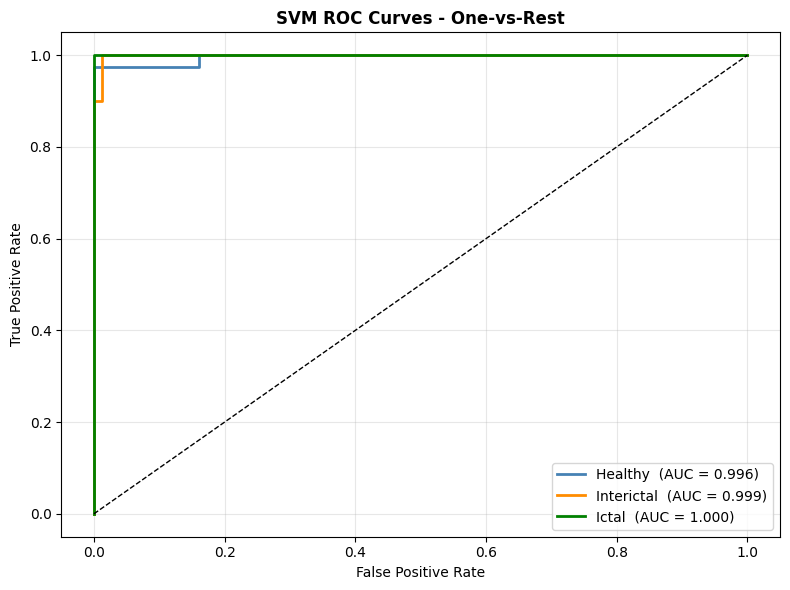

✓ Saved: svm_roc_curves.png


In [23]:
colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin_ovr[:, i], y_proba_svm[:, i])
    roc_auc_i   = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{label_names[i]}  (AUC = {roc_auc_i:.3f})')

plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curves - One-vs-Rest', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: svm_roc_curves.png')

## 22. Feature Importance (Permutation)

SVMs have no built-in feature importances for non-linear kernels. Permutation importance shuffles each PCA component and measures the resulting AUC drop.

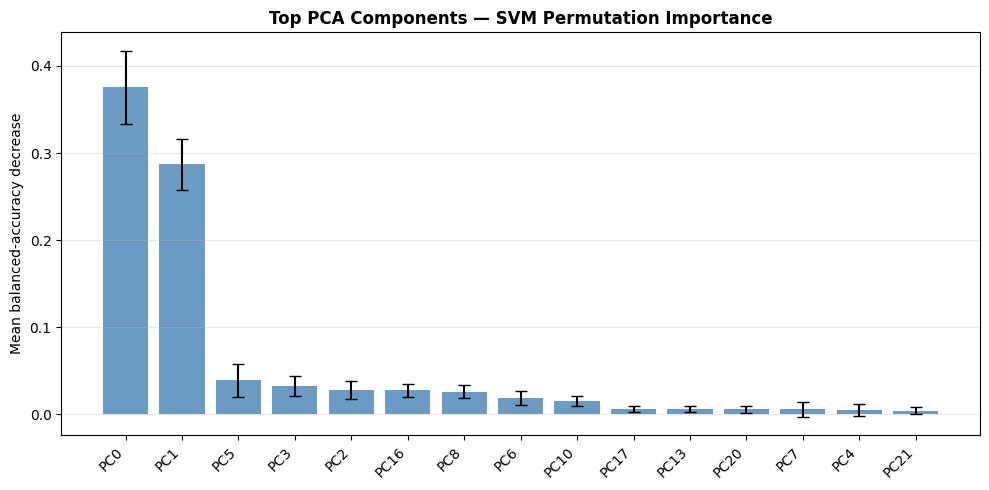

Saved: svm_feature_importance.png


In [24]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_svm, X_test, y_true_int,
    scoring      = 'balanced_accuracy',
    n_repeats    = 10,
    random_state = 42,
    n_jobs       = -1
)

sort_idx = np.argsort(perm.importances_mean)[::-1]
top_n    = min(15, len(sort_idx))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(top_n),
       perm.importances_mean[sort_idx[:top_n]],
       yerr   = perm.importances_std[sort_idx[:top_n]],
       color  = 'steelblue', alpha=0.8, capsize=4)
ax.set_xticks(range(top_n))
ax.set_xticklabels([f'PC{sort_idx[i]}' for i in range(top_n)],
                   rotation=45, ha='right')
ax.set_ylabel('Mean balanced-accuracy decrease')
ax.set_title('Top PCA Components — SVM Permutation Importance', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('svm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: svm_feature_importance.png')

## 23. CNN vs. SVM — Side-by-Side Comparison

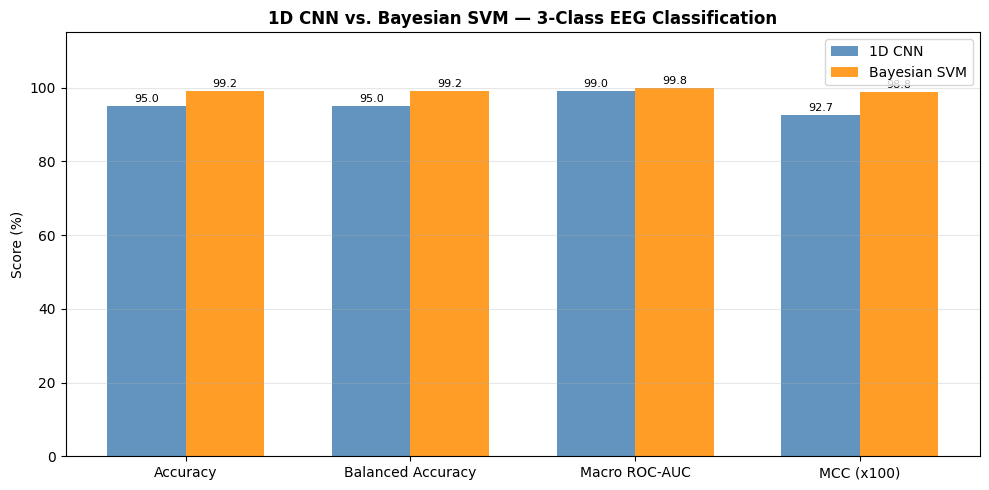


Model Comparison:
                      1D CNN  Bayesian SVM
Accuracy           95.041323     99.173554
Balanced Accuracy  95.000000     99.166667
Macro ROC-AUC      99.005445     99.825103
MCC (x100)         92.682067     98.770366


In [25]:
cnn_bal2 = balanced_accuracy_score(y_true, y_pred)
cnn_mcc2 = matthews_corrcoef(y_true, y_pred)

metrics = {
    'Accuracy'          : [test_acc * 100,  svm_acc * 100],
    'Balanced Accuracy' : [cnn_bal2 * 100,  svm_bal * 100],
    'Macro ROC-AUC'     : [macro_auc * 100, svm_auc * 100],
    'MCC (x100)'        : [cnn_mcc2 * 100,  svm_mcc * 100],
}

df_cmp = pd.DataFrame(metrics, index=['1D CNN', 'Bayesian SVM']).T

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_cmp))
w = 0.35
bars1 = ax.bar(x - w/2, df_cmp['1D CNN'],       w, label='1D CNN',       color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + w/2, df_cmp['Bayesian SVM'], w, label='Bayesian SVM', color='darkorange', alpha=0.85)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(df_cmp.index)
ax.set_ylabel('Score (%)')
ax.set_title('1D CNN vs. Bayesian SVM — 3-Class EEG Classification', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 115)
plt.tight_layout()
plt.savefig('cnn_vs_svm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nModel Comparison:')
print(df_cmp.to_string())

## 24. Save SVM Model

In [26]:
with open('svm_epilepsy_model.pkl', 'wb') as f:
    pkl.dump(best_svm, f)
print('SVM saved: svm_epilepsy_model.pkl')

with open('svm_best_params.json', 'w') as f:
    params_out = {k: (str(v) if v is None else v)
                  for k, v in bayes_search.best_params_.items()}
    json.dump({'best_cv_auc': bayes_search.best_score_,
               'best_params': params_out}, f, indent=2)
print('Best params saved: svm_best_params.json')

SVM saved: svm_epilepsy_model.pkl
Best params saved: svm_best_params.json


## 25. SVM Inference on New Samples

In [27]:
with open('svm_epilepsy_model.pkl', 'rb') as f:
    svm_loaded = pkl.load(f)


def predict_svm(raw_features):
    """
    Predict epilepsy class from a raw feature vector (pre-scaler/selector/PCA).
    raw_features: 1-D array matching rows in extracted_features.npy
    """
    x = pipeline['scaler'].transform(raw_features.reshape(1, -1))
    sel = pipeline['selector']
    if isinstance(sel, tuple):
        x = np.hstack([sel[0].transform(x), sel[1].transform(x)])
    else:
        x = sel.transform(x)
    x = pipeline['pca'].transform(x)        # (1, n_pca)

    proba = svm_loaded.predict_proba(x)[0]
    pred  = int(np.argmax(proba))
    return {
        'predicted_class': pred,
        'class_name'     : class_names.get(pred, str(pred)),
        'confidence'     : float(proba[pred]),
        'probabilities'  : {class_names.get(i, str(i)): float(p)
                            for i, p in enumerate(proba)}
    }


if os.path.exists('extracted_features.npy'):
    feats  = np.load('extracted_features.npy')
    result = predict_svm(feats[0])
    print('SVM demo prediction:')
    print(f'  Class      : {result["class_name"]}')
    print(f'  Confidence : {result["confidence"] * 100:.1f}%')
    print(f'  All probs  : {result["probabilities"]}')
else:
    print('Demo on X_test[0:3]:')
    p = svm_loaded.predict_proba(X_test[:3])
    for i, probs in enumerate(p):
        pred = int(np.argmax(probs))
        conf = probs[pred] * 100
        print(f'  Sample {i}: {class_names.get(pred)}  conf={conf:.1f}%')

SVM demo prediction:
  Class      : Healthy
  Confidence : 99.0%
  All probs  : {'Healthy': 0.9899948065885277, 'Interictal': 0.009632987382827791, 'Ictal': 0.00037220602864458815}


## 26. Full Pipeline Summary

In [28]:
print('MODEL 1 — 1D CNN  (3-class: Healthy / Interictal / Ictal)')
print(f'  Test Accuracy : {test_acc * 100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Macro AUC     : {macro_auc:.4f}')

print('MODEL 2 — Bayesian SVM  (3-class: Healthy / Interictal / Ictal)')
print(f'  Best CV AUC       : {bayes_search.best_score_:.4f}')
print(f'  Test Macro AUC    : {svm_auc:.4f}')
print(f'  Test Accuracy     : {svm_acc * 100:.2f}%')
print(f'  Balanced Accuracy : {svm_bal * 100:.2f}%')
print(f'  MCC               : {svm_mcc:.4f}')
print(f'  Best kernel       : {bayes_search.best_params_["svm__kernel"]}')
print(f'  Best C            : {bayes_search.best_params_["svm__C"]:.4f}')
print(f'  Best gamma        : {bayes_search.best_params_["svm__gamma"]:.6f}')

print('FILES')
print('  CNN : epilepsy_cnn_model.keras  |  checkpoints/best_model.keras')
print('  SVM : svm_epilepsy_model.pkl    |  svm_best_params.json')
print('  Plots: svm_convergence.png | svm_confusion_matrix.png')
print('         svm_roc_curves.png  | svm_feature_importance.png')
print('         cnn_vs_svm_comparison.png')

MODEL 1 — 1D CNN  (3-class: Healthy / Interictal / Ictal)
  Test Accuracy : 95.04%
  Test Loss     : 0.2247
  Macro AUC     : 0.9901
MODEL 2 — Bayesian SVM  (3-class: Healthy / Interictal / Ictal)
  Best CV AUC       : 0.9964
  Test Macro AUC    : 0.9983
  Test Accuracy     : 99.17%
  Balanced Accuracy : 99.17%
  MCC               : 0.9877
  Best kernel       : rbf
  Best C            : 22.4170
  Best gamma        : 0.005966
FILES
  CNN : epilepsy_cnn_model.keras  |  checkpoints/best_model.keras
  SVM : svm_epilepsy_model.pkl    |  svm_best_params.json
  Plots: svm_convergence.png | svm_confusion_matrix.png
         svm_roc_curves.png  | svm_feature_importance.png
         cnn_vs_svm_comparison.png
